In [1]:
%reload_ext autoreload
%autoreload 2
import py4DSTEM
import numpy as np
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
from matplotlib import ticker
from microstructure_inference.dataModules import cubic_proper_point_group_operations
from microstructure_inference.dataProcessing import point_in_spherical_triangle_oriented, assignment_cost_pairwise_distance,  sample_rotation_at_rand_geodesic_distance

In [2]:

trained_model_indicator_index = "sing_02"

model_path = os.getcwd() + "/"
geodesic_loss_path = model_path + "panel_d/"
data_path = model_path + "../"


In [3]:



Cu_cif = "Cu_fcc.cif"

pixel_size = 0.0328
excitation_error = 0.02
pixel_numbers = 128

k_max = pixel_size * pixel_numbers / 2.
accelerating_voltage = int(300e3)
crystal = py4DSTEM.process.diffraction.Crystal.from_CIF(data_path + Cu_cif)
crystal.setup_diffraction(accelerating_voltage)
crystal.calculate_structure_factors(
    k_max,
)

crystal.orientation_plan(
    angle_step_zone_axis = 2,
    angle_step_in_plane = 2,
    accel_voltage = 300e3,
    corr_kernel_size= 0.08, # was 0.08 before 0.12 not bad
    zone_axis_range='auto',
)


Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.
self.orientation_refine
 False 



Orientation plan: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 406/406 [00:00<00:00, 4880.72 zone axes/s]


Peak location_trained: 0.00563963963963964
Peak location_untrained: 0.7865045045045045


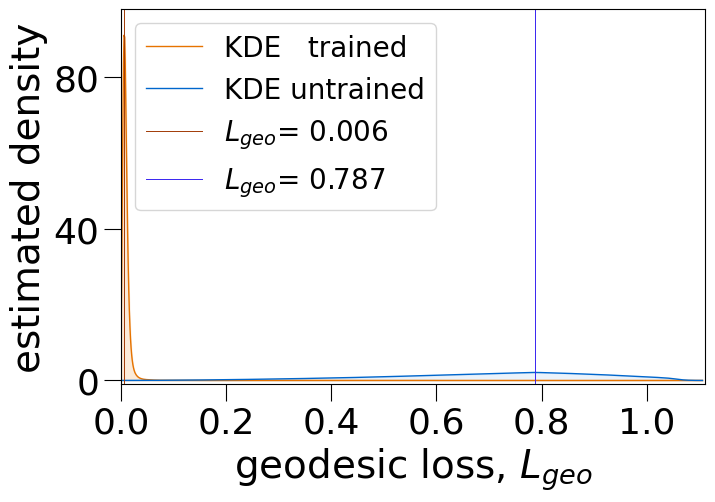

In [4]:

valid_set_geodesic_distances_trained = np.load(geodesic_loss_path + "geodesic_distances_trained_valid.npy")
valid_set_geodesic_distances_untrained = np.load(geodesic_loss_path + "geodesic_distances_untrained_valid.npy")


# Create KDE
lower_bound = 0.0
upper_bound = 1.096

# Evaluate KDE on a fine grid
kde_trained = gaussian_kde(valid_set_geodesic_distances_trained)
kde_untrained = gaussian_kde(valid_set_geodesic_distances_untrained)

x_grid = np.linspace(lower_bound-0.01, upper_bound+0.01, 1000)
kde_values_trained = kde_trained(x_grid)
kde_values_untrained = kde_untrained(x_grid)

# Find the peak (location of maximum density)
peak_location_trained = x_grid[np.argmax(kde_values_trained)]
print("Peak location_trained:", peak_location_trained)

peak_location_untrained = x_grid[np.argmax(kde_values_untrained)]
print("Peak location_untrained:", peak_location_untrained)

# Optional: plot

# Optional: plot
# fig, ax = plt.subplots(1, 1, figsize=(7.3, 5))
fig = plt.figure(figsize=(7.3, 5))
ax = fig.add_axes([0.15, 0.15, 0.8, 0.75])  # adjust these numbers to control the axes box

ax.plot(x_grid, kde_values_trained, label="KDE   trained", color = "#E67300", linewidth = 1.0)
ax.plot(x_grid, kde_values_untrained, label="KDE untrained", color = "#0066CC", linewidth = 1.0)
ax.axvline(peak_location_trained, color="#A13A06", linestyle="solid", label=r"$L_{geo}$" + f"= {peak_location_trained:4.3f}", linewidth = 0.7)
ax.axvline(peak_location_untrained, color="#3824F0", linestyle="solid", label=r"$L_{geo}$" + f"= {peak_location_untrained:4.3f}", linewidth = 0.7)
ax.fill_between(x_grid, kde_values_trained, alpha=0.15, color = "#E67300")
ax.fill_between(x_grid, kde_values_untrained, alpha=0.08, color = "#0066CC")

ax.legend(fontsize = 20)
ax.set_xlim([0.0,upper_bound+0.015])
ax.set_ylim([-1,98])
ax.set_yticks([0.0, 40, 80])
ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xlabel(r"geodesic loss, $L_{geo}$", fontsize = 28)
ax.set_ylabel(r"estimated density", fontsize = 28)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=26)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=26)
# plt.title("1D KDE plot of geodesic distance (valid data)", fontsize=20)
plt.savefig(geodesic_loss_path + trained_model_indicator_index + '_kde_geodesic_valid_set.pdf', bbox_inches='tight', dpi=300)
plt.show()

Peak location_trained: 0.013459459459459458
Peak location_untrained: 0.7820360360360361
50th percentile (CDF=0.5) location: 0.05590990990990991


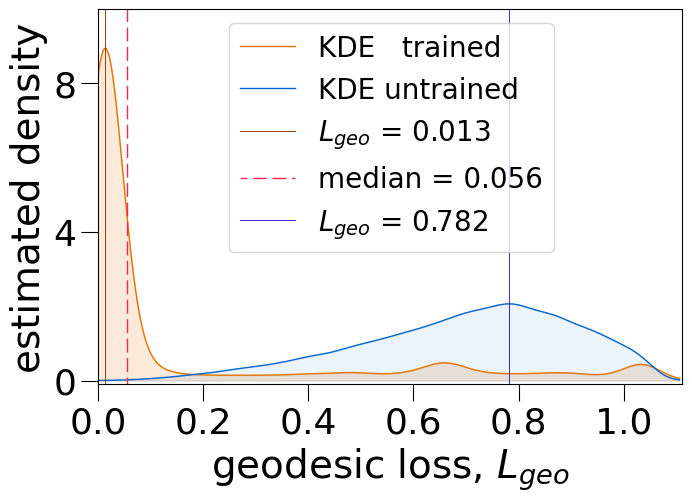

In [5]:


test_set_geodesic_distances_trained = np.load(geodesic_loss_path + "geodesic_distances_trained_test.npy")
test_set_geodesic_distances_untrained = np.load(geodesic_loss_path + "geodesic_distances_untrained_test.npy")



# Create KDE
kde_trained = gaussian_kde(test_set_geodesic_distances_trained)
kde_untrained = gaussian_kde(test_set_geodesic_distances_untrained)



# Evaluate KDE on a fine grid
x_grid = np.linspace(lower_bound-0.01, upper_bound+0.01, 1000)
kde_values_trained = kde_trained(x_grid)
kde_values_untrained = kde_untrained(x_grid)

        

# Find the peak (location of maximum density)
peak_location_trained = x_grid[np.argmax(kde_values_trained)]
print("Peak location_trained:", peak_location_trained)

peak_location_untrained = x_grid[np.argmax(kde_values_untrained)]
print("Peak location_untrained:", peak_location_untrained)

# Optional: plot

# Compute CDF by cumulative sum
dx = x_grid[1] - x_grid[0]  # spacing
cdf_trained = np.cumsum(kde_values_trained) * dx  # approximate CDF

# Find x where CDF = 0.8
trained_50_percentile_median = x_grid[np.searchsorted(cdf_trained, 0.5)]
print("50th percentile (CDF=0.5) location:", trained_50_percentile_median)

# fig, ax = plt.subplots(1, 1, figsize=(7.3, 5))
# # ax.plot(x_grid_points_where_kde_val_higher_than_threshold, kde_val_higher_than_threshold, label

# ax.plot(x_grid, kde_values_trained, label="KDE   trained", color = "#E67300", linewidth = 1.0)
# ax.fill_between(x_grid, kde_values_trained, alpha=0.15, color = "#E67300")
# #0066CC
# # ax.plot(x_grid_points_where_kde_val_higher_than_threshold, kde_val_higher_than_threshold, "X", kde_val_higher_than_threshold, label="high geo", color = "#6098E0")

# ax.plot(x_grid, kde_values_untrained, label="KDE untrained", color = "#0066CC", linewidth = 1.0)
# ax.fill_between(x_grid, kde_values_untrained, alpha=0.08, color = "#0066CC")
# #0A226B blue
# #3824F0 blue

# #CC5500 orange
# #FF8C00 orange

# ax.axvline(peak_location_trained, color="#A13A06", linestyle="solid", label=r"$L_{geo}$" + f" = {peak_location_trained:4.3f}", linewidth = 0.7)
# ax.axvline(trained_50_percentile_median, color="#F52750", linestyle=(5, (10,4)), label=r"median " + f"= {trained_50_percentile_median:4.3f}", linewidth = 1.0)
# ax.axvline(peak_location_untrained, color="#3824F0", linestyle="solid", label=r"$L_{geo}$" + f" = {peak_location_untrained:4.3f}", linewidth = 0.7)


# ax.legend(fontsize = 20,
#          loc='upper left',           # the anchor point of the legend box
#             bbox_to_anchor=(0.2, 1))
# ax.set_xlim([lower_bound-0.015,upper_bound+0.015])
# ax.set_ylim([-0.1,10])
# # ax.set_yscale('log')
# ax.set_yticks([0.0, 4, 8])
# ax.set_xlabel(r"geodesic loss, $L_{geo}$", fontsize = 28)
# ax.set_ylabel(r"estimated density", fontsize = 28)
# ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=26)
# ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=26)
# plt.savefig(geodesic_loss_path + trained_model_indicator_index + '_kde_geodesic_test_set.pdf', bbox_inches='tight', dpi=300)
# plt.show()



fig = plt.figure(figsize=(7.3, 5))
ax = fig.add_axes([0.15, 0.15, 0.8, 0.75])  # adjust these numbers to control the axes box
ax.plot(x_grid, kde_values_trained, label="KDE   trained", color = "#E67300", linewidth = 1.0)
ax.fill_between(x_grid, kde_values_trained, alpha=0.15, color = "#E67300")
ax.plot(x_grid, kde_values_untrained, label="KDE untrained", color = "#0066CC", linewidth = 1.0)
ax.fill_between(x_grid, kde_values_untrained, alpha=0.08, color = "#0066CC")
ax.axvline(peak_location_trained, color="#A13A06", linestyle="solid", label=r"$L_{geo}$" + f" = {peak_location_trained:4.3f}", linewidth = 0.7)
ax.axvline(trained_50_percentile_median, color="#F52750", linestyle=(5, (10,4)), label=r"median " + f"= {trained_50_percentile_median:4.3f}", linewidth = 1.0)
ax.axvline(peak_location_untrained, color="#3824F0", linestyle="solid", label=r"$L_{geo}$" + f" = {peak_location_untrained:4.3f}", linewidth = 0.7)
# ax.plot(1.0437827, 0.0000000001, "X", label="worst", color = "#000000", markersize = 15, zorder=10)
ax.legend(fontsize = 20,
         loc='upper left',           # the anchor point of the legend box
            bbox_to_anchor=(0.2, 1))
ax.set_xlim([0.0,upper_bound+0.015])
ax.set_ylim([-0.1,10])
# ax.set_yscale('log')
ax.set_yticks([0.0, 4, 8])
ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xlabel(r"geodesic loss, $L_{geo}$", fontsize = 28)
ax.set_ylabel(r"estimated density", fontsize = 28)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=26)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=26)
# plt.title("1D KDE plot of geodesic distance (test data)", fontsize=20)
plt.savefig(geodesic_loss_path + trained_model_indicator_index + '_kde_geodesic_test_set_with_x.pdf', bbox_inches='tight', dpi=300)
plt.show()

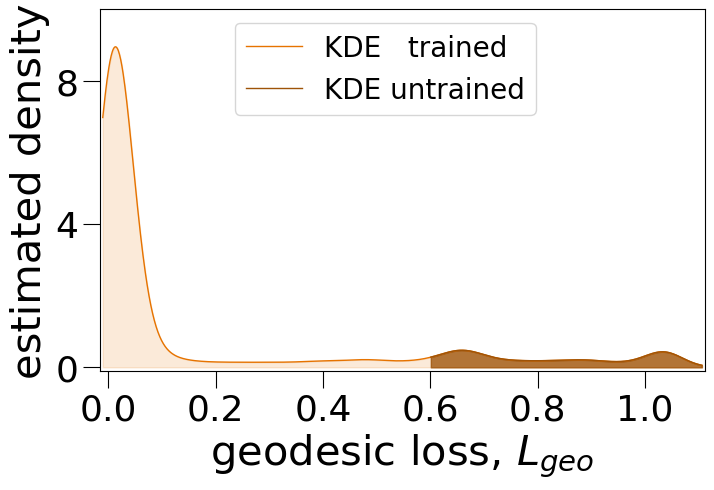

In [21]:
geodesic_loss_threshold = 0.6

test_set_x_grid_points_where_higher_than_threshold = [] 
test_set_kde_density_estimate_val_where_x_grid_points_where_higher_than_threshold = []



for index, x_grid_val in enumerate(x_grid):
    if x_grid_val > geodesic_loss_threshold:
        test_set_x_grid_points_where_higher_than_threshold.append(x_grid_val)
        test_set_kde_density_estimate_val_where_x_grid_points_where_higher_than_threshold.append(kde_values_trained[index])


test_set_x_grid_points_where_higher_than_threshold = np.array(test_set_x_grid_points_where_higher_than_threshold)
test_set_kde_density_estimate_val_where_x_grid_points_where_higher_than_threshold = np.array(test_set_kde_density_estimate_val_where_x_grid_points_where_higher_than_threshold)

fig, ax = plt.subplots(1, 1, figsize=(7.8, 4.7))
# ax.plot(x_grid_points_where_kde_val_higher_than_threshold, kde_val_higher_than_threshold, label

ax.plot(x_grid, kde_values_trained, label="KDE   trained", color = "#E67300", linewidth = 1.0)
ax.fill_between(x_grid, kde_values_trained, alpha=0.15, color = "#E67300")

ax.plot(test_set_x_grid_points_where_higher_than_threshold, test_set_kde_density_estimate_val_where_x_grid_points_where_higher_than_threshold, label="KDE untrained", color = "#9E5308", linewidth = 1.0)
ax.fill_between(test_set_x_grid_points_where_higher_than_threshold, test_set_kde_density_estimate_val_where_x_grid_points_where_higher_than_threshold, alpha=0.78, color = "#9E5308")
#0A226B blue
#3824F0 blue

#CC5500 orange
#FF8C00 orange

# ax.axvline(peak_location_trained, color="#A13A06", linestyle="solid", label=r"$L_{geo}$" + f" = {peak_location_trained:4.3f}", linewidth = 0.7)
# ax.axvline(trained_50_percentile_median, color="#F52750", linestyle=(5, (10,4)), label=r"median " + f"= {trained_50_percentile_median:4.3f}", linewidth = 1.0)
# ax.axvline(peak_location_untrained, color="#3824F0", linestyle="solid", label=r"$L_{geo}$" + f" = {peak_location_untrained:4.3f}", linewidth = 0.7)


ax.legend(fontsize = 20,
         loc='upper left',           # the anchor point of the legend box
            bbox_to_anchor=(0.2, 1))
ax.set_xlim([lower_bound-0.015,upper_bound+0.015])
ax.set_ylim([-0.1,10])
# ax.set_yscale('log')
ax.set_yticks([0.0, 4, 8])
ax.set_xticks([0.0, 0.2, 0.4,0.6,0.8,1.0])
ax.set_xlabel(r"geodesic loss, $L_{geo}$", fontsize = 30)
ax.set_ylabel(r"estimated density", fontsize = 30)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=26)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=26)
plt.savefig(geodesic_loss_path + trained_model_indicator_index + '_kde_geodesic_test_set_vals_higher_than_0.6_highlighted.pdf', bbox_inches='tight', dpi=300)
plt.show()
